<h1>Import necessary library<h1>

In [1]:
import os
import torch  
from torchvision import datasets, transforms, models 
from torch. utils.data import DataLoader, dataset, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.utils import save_image
from torchvision.transforms.functional import resize, InterpolationMode
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import sqrtm
from torch.nn.functional import adaptive_avg_pool2d


<h1>Data Collection and Preprocessing<h1>

In [5]:


class SkinDataset(Dataset):
    def __init__(self, normal_images, lumpy_images, transform=None, augment=False, mode='train'):
        self.normal_images = normal_images
        self.lumpy_images = lumpy_images
        self.transform = transform
        self.augment = augment
        self.mode = mode  

        
        self.final_transform = transforms.Compose([
            transforms.ToTensor(),  
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  
        ])
        self.final_transform_val = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
        self.lumpy_augment_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(20),      
            transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),  
            transforms.RandomResizedCrop(size=(256, 256), scale=(0.8, 1.0), ratio=(0.9, 1.1)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) 
        ])

    def __len__(self):
        return max(len(self.normal_images), len(self.lumpy_images))

    def __getitem__(self, idx):
        normal_img_path = self.normal_images[idx % len(self.normal_images)]
        lumpy_img_path = self.lumpy_images[idx % len(self.lumpy_images)]

        normal_img = Image.open(normal_img_path).convert("RGB")
        lumpy_img = Image.open(lumpy_img_path).convert("RGB")

        normal_img = self.final_transform(normal_img)

        if self.augment:
            lumpy_img = self.lumpy_augment_transform(lumpy_img)
        else:
            
            lumpy_img = self.final_transform(lumpy_img)

        return {
            'A': normal_img,
            'B': lumpy_img,
            'A_path': normal_img_path,
            'B_path': lumpy_img_path
        }



<h1>Data Preprocessing<h1>

In [8]:
normal_dir = "/workspace/archive/Lumpy Skin Images Dataset/Normal Skin"
lumpy_dir = "/workspace/archive/Lumpy Skin Images Dataset/Lumpy Skin"

normal_images = [os.path.join(normal_dir, f) for f in os.listdir(normal_dir) if f.endswith(('.jpg', '.png'))]
lumpy_images = [os.path.join(lumpy_dir, f) for f in os.listdir(lumpy_dir) if f.endswith(('.jpg', '.png'))]

print(f"Total Normal Skin images: {len(normal_images)}")
print(f"Total Lumpy Skin images: {len(lumpy_images)}")

normal_train, normal_remaining = train_test_split(normal_images, test_size=0.2, random_state=42)
lumpy_train, lumpy_remaining = train_test_split(lumpy_images, test_size=0.2, random_state=42)

normal_val, normal_test = train_test_split(normal_remaining, test_size=0.5, random_state=42)
lumpy_val, lumpy_test = train_test_split(lumpy_remaining, test_size=0.5, random_state=42)

print(f"Normal Skin Training images: {len(normal_train)}")
print(f"Normal Skin Validation images: {len(normal_val)}")
print(f"Normal Skin Test images: {len(normal_test)}")
print(f"Lumpy Skin Training images: {len(lumpy_train)}")
print(f"Lumpy Skin Validation images: {len(lumpy_val)}")
print(f"Lumpy Skin Test images: {len(lumpy_test)}")

transform = transforms.Compose([
    transforms.Resize((256, 256)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) 
])
train_dataset = SkinDataset(normal_train, lumpy_train, transform=transform, augment=True)
val_dataset = SkinDataset(normal_val, lumpy_val, transform=transform, augment=False)
test_dataset = SkinDataset(normal_test, lumpy_test, transform=transform, augment=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4)

for batch in train_loader:
    print("Batch of Normal Skin Images (A):", batch['A'].shape)
    print("Batch of Lumpy Skin Images (B):", batch['B'].shape) 
    break


Total Normal Skin images: 700
Total Lumpy Skin images: 324
Normal Skin Training images: 560
Normal Skin Validation images: 70
Normal Skin Test images: 70
Lumpy Skin Training images: 259
Lumpy Skin Validation images: 32
Lumpy Skin Test images: 33
Train dataset size: 560
Validation dataset size: 70
Test dataset size: 70
Batch of Normal Skin Images (A): torch.Size([16, 3, 256, 256])
Batch of Lumpy Skin Images (B): torch.Size([16, 3, 256, 256])


<h1>CYCLEGAN architecture for data augmentation<h1>

In [11]:

class InstanceNormalization(nn.Module):
    def __init__(self, dim, epsilon=1e-5):
        super(InstanceNormalization, self).__init__()
        self.epsilon = epsilon
        self.scale = nn.Parameter(torch.ones(dim))
        self.offset = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        mean = x.mean([2, 3], keepdim=True)
        var = x.var([2, 3], keepdim=True, unbiased=False)
        x = (x - mean) / torch.sqrt(var + self.epsilon)
        return self.scale[:, None, None] * x + self.offset[:, None, None]

# Define the Discriminator model
class Discriminator(nn.Module):
    def __init__(self, input_shape):
        super(Discriminator, self).__init__()
        
        self.model = nn.Sequential(
            # C64
            nn.Conv2d(input_shape[0], 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # C128
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            InstanceNormalization(128),
            nn.LeakyReLU(0.2, inplace=True),

            # C256
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            InstanceNormalization(256),
            nn.LeakyReLU(0.2, inplace=True),

            # C512
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            InstanceNormalization(512),
            nn.LeakyReLU(0.2, inplace=True),

            # PatchGAN output
            nn.Conv2d(512, 1, kernel_size=4, padding=1)
        )
        self.apply(self.init_weights)

    def forward(self, x):
        return self.model(x)

    # Initialize weights
    def init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_shape = (3, 256, 256)  

d_model_A = Discriminator(input_shape).to(device) 
d_model_B = Discriminator(input_shape).to(device) 

for param in d_model_A.parameters():
    print(f"Discriminator A Param requires_grad: {param.requires_grad}")

for param in d_model_B.parameters():
    print(f"Discriminator B Param requires_grad: {param.requires_grad}")

optim_d = optim.Adam(
    list(d_model_A.parameters()) + list(d_model_B.parameters()),
    lr=0.0002,
    betas=(0.5, 0.999)
)

print("Discriminator A Model:", d_model_A)
print("Discriminator B Model:", d_model_B)
print("Optimizer for Discriminators:", optim_d)


Discriminator A Param requires_grad: True
Discriminator A Param requires_grad: True
Discriminator A Param requires_grad: True
Discriminator A Param requires_grad: True
Discriminator A Param requires_grad: True
Discriminator A Param requires_grad: True
Discriminator A Param requires_grad: True
Discriminator A Param requires_grad: True
Discriminator A Param requires_grad: True
Discriminator A Param requires_grad: True
Discriminator A Param requires_grad: True
Discriminator A Param requires_grad: True
Discriminator A Param requires_grad: True
Discriminator A Param requires_grad: True
Discriminator A Param requires_grad: True
Discriminator A Param requires_grad: True
Discriminator B Param requires_grad: True
Discriminator B Param requires_grad: True
Discriminator B Param requires_grad: True
Discriminator B Param requires_grad: True
Discriminator B Param requires_grad: True
Discriminator B Param requires_grad: True
Discriminator B Param requires_grad: True
Discriminator B Param requires_gra

<h1>Generator<h1>

In [13]:
class ResnetBlock(nn.Module):
    def __init__(self, n_filters):
        super(ResnetBlock, self).__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1), 
            nn.Conv2d(n_filters, n_filters, kernel_size=3),
            InstanceNormalization(n_filters),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(n_filters, n_filters, kernel_size=3),
            InstanceNormalization(n_filters)
        )

    def forward(self, x):
        return x + self.block(x)  

In [14]:

class InstanceNormalization(nn.Module):
    def __init__(self, dim, epsilon=1e-5):
        super(InstanceNormalization, self).__init__()
        self.epsilon = epsilon
        self.scale = nn.Parameter(torch.ones(dim))
        self.offset = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        mean = x.mean([2, 3], keepdim=True)
        var = x.var([2, 3], keepdim=True, unbiased=False)
        x = (x - mean) / torch.sqrt(var + self.epsilon)
        return self.scale[:, None, None] * x + self.offset[:, None, None]


class ResnetBlock(nn.Module):
    def __init__(self, n_filters):
        super(ResnetBlock, self).__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1), 
            nn.Conv2d(n_filters, n_filters, kernel_size=3),
            InstanceNormalization(n_filters),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(n_filters, n_filters, kernel_size=3),
            InstanceNormalization(n_filters)
        )

    def forward(self, x):
        return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, input_channels=3, output_channels=3, n_resnet=9):
        super(Generator, self).__init__()

        # Initial Convolutional layer
        self.c7s1_64 = nn.Sequential(
            nn.ReflectionPad2d(3),  
            nn.Conv2d(input_channels, 64, kernel_size=7),
            InstanceNormalization(64),
            nn.ReLU(inplace=True)
        )

        # Downsampling layers
        self.d128 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            InstanceNormalization(128),
            nn.ReLU(inplace=True)
        )
        self.d256 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            InstanceNormalization(256),
            nn.ReLU(inplace=True)
        )

        # ResNet blocks
        self.res_blocks = nn.Sequential(*[ResnetBlock(256) for _ in range(n_resnet)])

        # Upsampling layers
        self.u128 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            InstanceNormalization(128),
            nn.ReLU(inplace=True)
        )
        self.u64 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            InstanceNormalization(64),
            nn.ReLU(inplace=True)
        )

        # Final output layer
        self.c7s1_3 = nn.Sequential(
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, output_channels, kernel_size=7),
            nn.Tanh()  
        )

        self._initialize_weights() 

    def forward(self, x):
        x = self.c7s1_64(x)
        x = self.d128(x)
        x = self.d256(x)
        x = self.res_blocks(x)
        x = self.u128(x)
        x = self.u64(x)
        return self.c7s1_3(x)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.normal_(m.weight, 0.0, 0.02)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

g_model_AtoB = Generator(input_channels=3, output_channels=3, n_resnet=9).to(device)  
g_model_BtoA = Generator(input_channels=3, output_channels=3, n_resnet=9).to(device) 

def check_gradients(model, name):
    print(f"{name} Model Parameters require_grad:")
    print(all(param.requires_grad for param in model.parameters()))  

check_gradients(g_model_AtoB, "AtoB")
check_gradients(g_model_BtoA, "BtoA")

optim_g = optim.Adam(
    list(g_model_AtoB.parameters()) + list(g_model_BtoA.parameters()), 
    lr=0.0002, betas=(0.5, 0.999)
)
print("Generator AtoB:", g_model_AtoB)
print("Generator BtoA:", g_model_BtoA)
print("Optimizer for Generators:", optim_g)


AtoB Model Parameters require_grad:
True
BtoA Model Parameters require_grad:
True
Generator AtoB: Generator(
  (c7s1_64): Sequential(
    (0): ReflectionPad2d((3, 3, 3, 3))
    (1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1))
    (2): InstanceNormalization()
    (3): ReLU(inplace=True)
  )
  (d128): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): InstanceNormalization()
    (2): ReLU(inplace=True)
  )
  (d256): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): InstanceNormalization()
    (2): ReLU(inplace=True)
  )
  (res_blocks): Sequential(
    (0): ResnetBlock(
      (block): Sequential(
        (0): ReflectionPad2d((1, 1, 1, 1))
        (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
        (2): InstanceNormalization()
        (3): ReLU(inplace=True)
        (4): ReflectionPad2d((1, 1, 1, 1))
        (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
        (6): In

<h1>Composite model<h1>

In [16]:


# Composite Model
class CompositeModel(nn.Module):
    def __init__(self, g_model_AtoB, d_model_A, g_model_BtoA, d_model_B):
        super(CompositeModel, self).__init__()
        self.g_model_AtoB = g_model_AtoB  
        self.d_model_A = d_model_A        
        self.g_model_BtoA = g_model_BtoA  
        self.d_model_B = d_model_B        

        for param in self.d_model_A.parameters():
            param.requires_grad = False
        for param in self.d_model_B.parameters():
            param.requires_grad = False

    def forward(self, input_gen, input_id):
        
        gen1_out = self.g_model_AtoB(input_gen)
        
        output_f = self.g_model_BtoA(gen1_out)
        
        output_id = self.g_model_AtoB(input_id)
        
        gen2_out = self.g_model_BtoA(input_id)
        output_b = self.g_model_AtoB(gen2_out)
        
        return gen1_out, output_f, output_id, output_b

mse_loss = nn.MSELoss()  
mae_loss = nn.L1Loss()  

def train_composite_model(composite_model, real_A, real_B, optimizer, d_model_A, d_model_B, loss_weights=[1, 5, 10, 10]):
    optimizer.zero_grad()
    
    # Generator forward pass
    gen_B, cycle_A, id_AtoB, cycle_B = composite_model(real_A, real_B)

    # Adversarial losses
    pred_fake_B = d_model_B(gen_B)
    adversarial_loss_B = mse_loss(pred_fake_B, torch.ones_like(pred_fake_B)) * loss_weights[0]
    
    # Cycle consistency loss
    cycle_loss_A = mae_loss(cycle_A, real_A) * loss_weights[2]  
    cycle_loss_B = mae_loss(cycle_B, real_B) * loss_weights[3]  

    # Identity loss
    identity_loss = mae_loss(id_AtoB, real_B) * loss_weights[1]  

    # Total generator loss
    total_loss = adversarial_loss_B + cycle_loss_A + cycle_loss_B + identity_loss
    total_loss.backward()
    optimizer.step()

    return total_loss.item()

# Initialize models
g_model_AtoB = Generator(input_channels=3, output_channels=3).to(device)
g_model_BtoA = Generator(input_channels=3, output_channels=3).to(device)
d_model_A = Discriminator(input_shape=(3, 256, 256)).to(device)
d_model_B = Discriminator(input_shape=(3, 256, 256)).to(device)

# Composite model
composite_model = CompositeModel(g_model_AtoB, d_model_A, g_model_BtoA, d_model_B)

# Optimizer
optim_g = optim.Adam(
    list(g_model_AtoB.parameters()) + list(g_model_BtoA.parameters()),
    lr=0.0002, betas=(0.5, 0.999)
)

print("Composite Model Initialized.")


Composite Model Initialized.


In [17]:


class SkinDataset(Dataset):
    def __init__(self, normal_image_dir, lumpy_image_dir, transform=None, augment=False, mode='train'):
        self.normal_image_dir = normal_image_dir
        self.lumpy_image_dir = lumpy_image_dir
        self.transform = transform
        self.augment = augment
        self.mode = mode  

        # Get all image files in the directories
        self.normal_images = [f for f in os.listdir(normal_image_dir) if os.path.isfile(os.path.join(normal_image_dir, f)) and f.endswith(('.jpg', '.png'))]
        self.lumpy_images = [f for f in os.listdir(lumpy_image_dir) if os.path.isfile(os.path.join(lumpy_image_dir, f)) and f.endswith(('.jpg', '.png'))]

        if not self.transform:
            self.transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
            ])

        self.lumpy_augment_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),  
            transforms.RandomRotation(20),     
            transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),  
            transforms.RandomResizedCrop(size=(256, 256), scale=(0.8, 1.0), ratio=(0.9, 1.1)),  
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) 
        ])

    def __len__(self):
        return max(len(self.normal_images), len(self.lumpy_images))

    def __getitem__(self, idx):
        normal_img_path = os.path.join(self.normal_image_dir, random.choice(self.normal_images))
        lumpy_img_path = os.path.join(self.lumpy_image_dir, random.choice(self.lumpy_images))

        try:
            normal_img = Image.open(normal_img_path).convert("RGB")
            lumpy_img = Image.open(lumpy_img_path).convert("RGB")
        except Exception as e:
            print(f"Error opening images: {normal_img_path}, {lumpy_img_path}. Error: {e}")
            return self.__getitem__((idx + 1) % len(self))

        normal_img = self.transform(normal_img)

        if self.augment:
            lumpy_img = self.lumpy_augment_transform(lumpy_img)
        else:
            lumpy_img = self.transform(lumpy_img)
        
        return {
            'A': normal_img,
            'B': lumpy_img,
            'A_path': normal_img_path,
            'B_path': lumpy_img_path
        }


normal_image_dir = "/workspace/archive/Lumpy Skin Images Dataset/Normal Skin"
lumpy_image_dir = "/workspace/archive/Lumpy Skin Images Dataset/Lumpy Skin"

dataset = SkinDataset(
    normal_image_dir=normal_image_dir,
    lumpy_image_dir=lumpy_image_dir,
    transform=None,  
    augment=False   
)

train_size = 819  
val_size = 102    
test_size = 103   

train_indices = list(range(train_size))
valid_indices = list(range(train_size, train_size + val_size))
test_indices = list(range(train_size + val_size, train_size + val_size + test_size))

# Subset the dataset using the indices
train_dataset = Subset(SkinDataset(
    normal_image_dir=normal_image_dir,
    lumpy_image_dir=lumpy_image_dir,
    transform=None,
    augment=True,  
    mode='train'
), train_indices)

valid_dataset = Subset(SkinDataset(
    normal_image_dir=normal_image_dir,
    lumpy_image_dir=lumpy_image_dir,
    transform=None,
    augment=False,  
    mode='val'
), valid_indices)

test_dataset = Subset(SkinDataset(
    normal_image_dir=normal_image_dir,
    lumpy_image_dir=lumpy_image_dir,
    transform=None,
    augment=False,  
    mode='test'
), test_indices)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


In [19]:

def generate_real_samples(dataset, n_samples, patch_shape, domain='A', device='cpu'):
    indices = np.random.randint(0, len(dataset), n_samples)
    images = torch.stack([dataset[i][domain] for i in indices]).to(device)
    labels = torch.ones((n_samples, 1, patch_shape, patch_shape), dtype=torch.float32).to(device)  
    
    return images, labels

In [20]:

def generate_fake_samples(g_model, real_images, patch_shape, device='cpu'):
    with torch.no_grad():  
        fake_images = g_model(real_images.to(device))
    
    labels = torch.zeros((fake_images.size(0), 1, patch_shape, patch_shape), dtype=torch.float32).to(device)
    
    return fake_images, labels


In [21]:

def denormalize(tensor):
    return (tensor + 1) / 2
    
def save_synthetic_images_with_balanced_dataset(
    g_model_AtoB, g_model_BtoA, dataset, save_dir_lumpy, save_dir_healthy,
    original_healthy_count=560, original_lumpy_count=259, target_healthy_count=1120, target_lumpy_count=1078,
    resize_to=(256, 256), interpolation_method=InterpolationMode.BICUBIC
):
    """
    Generate synthetic images to balance the dataset and save them after training is complete.
    Arguments:
        g_model_AtoB (torch.nn.Module): Generator model to create healthy from lumpy.
        g_model_BtoA (torch.nn.Module): Generator model to create lumpy from healthy.
        dataset (list): The dataset containing original image pairs.
        save_dir_lumpy (str): Path to save generated lumpy images.
        save_dir_healthy (str): Path to save generated healthy images.
        original_healthy_count (int): Number of original healthy images.
        original_lumpy_count (int): Number of original lumpy images.
        target_healthy_count (int): Desired number of healthy images after augmentation.
        target_lumpy_count (int): Desired number of lumpy images after augmentation.
        resize_to (tuple): Target size for resizing images.
        interpolation_method (InterpolationMode): Interpolation method for resizing (InterpolationMode enum).
    """
    os.makedirs(save_dir_lumpy, exist_ok=True)
    os.makedirs(save_dir_healthy, exist_ok=True)

    device = next(g_model_AtoB.parameters()).device
    g_model_AtoB.eval()
    g_model_BtoA.eval()

    healthy_images_needed = target_healthy_count - original_healthy_count
    lumpy_images_needed = target_lumpy_count - original_lumpy_count

    augmented_healthy_count = 0
    augmented_lumpy_count = 0

    def get_unique_filename(directory, filename):
        base, ext = os.path.splitext(filename)
        counter = 1
        new_filename = filename
        while os.path.exists(os.path.join(directory, new_filename)):
            new_filename = f"{base}_{counter}{ext}"
            counter += 1
        return new_filename
        
    for data in tqdm(dataset, desc="Generating synthetic images"):
        real_A = data['A'].unsqueeze(0).to(device)
        real_B = data['B'].unsqueeze(0).to(device)

        
        original_lumpy_name = os.path.basename(data['A_path'])  
        original_healthy_name = os.path.basename(data['B_path'])  
        
        synthetic_healthy_name = f"Healthy_{augmented_healthy_count + 1}.png"
        synthetic_lumpy_name = f"Lumpy_{augmented_lumpy_count + 1}.png"


        with torch.no_grad():
            fake_healthy = g_model_AtoB(real_A)  
            fake_lumpy = g_model_BtoA(real_B)  # 

        
        fake_healthy = denormalize(fake_healthy.squeeze(0))  
        fake_lumpy = denormalize(fake_lumpy.squeeze(0))  

        fake_healthy = resize(fake_healthy, resize_to, interpolation=interpolation_method)
        fake_lumpy = resize(fake_lumpy, resize_to, interpolation=interpolation_method)

        # Save synthetic images
        if augmented_healthy_count < healthy_images_needed:
            unique_healthy_name = get_unique_filename(save_dir_healthy, synthetic_healthy_name)
            save_image(fake_healthy, os.path.join(save_dir_healthy, unique_healthy_name))
            augmented_healthy_count += 1

        if augmented_lumpy_count < lumpy_images_needed:
            unique_lumpy_name = get_unique_filename(save_dir_lumpy, synthetic_lumpy_name)
            save_image(fake_lumpy, os.path.join(save_dir_lumpy, unique_lumpy_name))
            augmented_lumpy_count += 1

        
        if augmented_healthy_count >= healthy_images_needed and augmented_lumpy_count >= lumpy_images_needed:
            break

    print(f"> Synthetic images saved to {save_dir_lumpy} and {save_dir_healthy}.")
    print(f"> Total synthetic healthy skin images generated: {augmented_healthy_count}")
    print(f"> Total synthetic lumpy skin images generated: {augmented_lumpy_count}")


In [22]:


def save_qualitative_results(epoch, g_model_AtoB, g_model_BtoA, dataset, save_dir="qualitative"):
    """
    Save qualitative results of the CycleGAN model for domain translation.

    Args:
        epoch (int): Current epoch.
        g_model_AtoB (torch.nn.Module): Generator model for domain A → B.
        g_model_BtoA (torch.nn.Module): Generator model for domain B → A.
        dataset (iterable): Dataset providing paired samples with keys 'A' and 'B'.
        save_dir (str): Directory to save qualitative results.
    """
    os.makedirs(save_dir, exist_ok=True)
    device = next(g_model_AtoB.parameters()).device

    for idx, sample in enumerate(dataset):
        real_A = sample['A'].unsqueeze(0).to(device)  
        real_B = sample['B'].unsqueeze(0).to(device)  

        with torch.no_grad():
            fake_B = g_model_AtoB(real_A)  
            reconstructed_A = g_model_BtoA(fake_B)  
            fake_A = g_model_BtoA(real_B)  
            reconstructed_B = g_model_AtoB(fake_A)  

        def tensor_to_image(tensor):
            img = tensor.cpu().squeeze(0).numpy().transpose(1, 2, 0)
            img = (img + 1) / 2.0  
            return img

        original_A = tensor_to_image(real_A)
        synthetic_B = tensor_to_image(fake_B)
        reconstructed_A = tensor_to_image(reconstructed_A)
        original_B = tensor_to_image(real_B)
        synthetic_A = tensor_to_image(fake_A)
        reconstructed_B = tensor_to_image(reconstructed_B)

        fig, axs = plt.subplots(2, 3, figsize=(12, 8))
        
        axs[0, 0].imshow(original_A)
        axs[0, 0].set_title("Original A (A)")
        axs[0, 0].axis("off")
        
        axs[0, 1].imshow(synthetic_B)
        axs[0, 1].set_title("Synthetic B (A → B)")
        axs[0, 1].axis("off")
        
        axs[0, 2].imshow(reconstructed_A)
        axs[0, 2].set_title("Reconstructed A (A → B → A)")
        axs[0, 2].axis("off")
        
        axs[1, 0].imshow(original_B)
        axs[1, 0].set_title("Original B (B)")
        axs[1, 0].axis("off")
        
        axs[1, 1].imshow(synthetic_A)
        axs[1, 1].set_title("Synthetic A (B → A)")
        axs[1, 1].axis("off")
        
        axs[1, 2].imshow(reconstructed_B)
        axs[1, 2].set_title("Reconstructed B (B → A → B)")
        axs[1, 2].axis("off")

        plt.tight_layout()
        qualitative_path = os.path.join(save_dir, f"qualitative_epoch{epoch:03d}_{idx + 1:04d}.png")
        
        try:
            plt.savefig(qualitative_path)
        except Exception as e:
            print(f"Error saving image {qualitative_path}: {e}")
        finally:
            plt.close(fig)


In [23]:
def save_models(step, g_model_AtoB, g_model_BtoA, save_dir="saved_models", model_type="training", save_interval=5):
    """
    Save models for training or validation in the lumpy skin disease detection project.

    Args:
        step (int): Current epoch or step.
        g_model_AtoB (torch.nn.Module): Generator model for domain A → B.
        g_model_BtoA (torch.nn.Module): Generator model for domain B → A.
        save_dir (str): Base directory to save models.
        model_type (str): Type of model saving ("training" or "validation").
        save_interval (int): Save models only at intervals of this step.
    """
    if step % save_interval != 0:
        return

    if model_type not in {"training", "validation"}:
        raise ValueError(f"Invalid model_type '{model_type}'. Supported types: 'training', 'validation'.")

    if not os.path.exists(save_dir):
        os.makedirs(save_dir, exist_ok=True)

    save_path = os.path.join(save_dir, f"{model_type}_models")
    os.makedirs(save_path, exist_ok=True)

    filename1 = os.path.join(save_path, f'g_model_AtoB_{step:06d}.pth')
    filename2 = os.path.join(save_path, f'g_model_BtoA_{step:06d}.pth')

    try:
        
        device_AtoB = next(g_model_AtoB.parameters()).device
        device_BtoA = next(g_model_BtoA.parameters()).device

        g_model_AtoB_cpu = g_model_AtoB.to('cpu')
        g_model_BtoA_cpu = g_model_BtoA.to('cpu')

        torch.save(g_model_AtoB_cpu.state_dict(), filename1)
        torch.save(g_model_BtoA_cpu.state_dict(), filename2)

        
        g_model_AtoB.to(device_AtoB)
        g_model_BtoA.to(device_BtoA)

        print(f'> Saved models at step {step}:')
        print(f'    {filename1}')
        print(f'    {filename2}')
    except Exception as e:
        print(f'Error saving models at step {step}: {e}')


In [24]:


def tensor_to_image(tensor):
    img = tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0)  
    img = (img + 1) / 2.0  
    return np.clip(img, 0, 1)


def visualize_results_with_reconstruction(g_model_normal_to_lumpy, g_model_lumpy_to_normal, dataset, num_samples=5, save_results=False, save_dir="visualizations"):
    """
    Visualize real, synthetic, and reconstructed images for the lumpy skin disease detection project.

    Args:
        g_model_normal_to_lumpy (torch.nn.Module): Generator model for normal → lumpy skin.
        g_model_lumpy_to_normal (torch.nn.Module): Generator model for lumpy skin → normal.
        dataset (torch.utils.data.Dataset): The dataset for generating samples.
        num_samples (int): Number of samples to visualize.
        save_results (bool): Whether to save the visualizations as images.
        save_dir (str): Directory to save the visualizations if save_results is True.
    """
    g_model_normal_to_lumpy.eval()
    g_model_lumpy_to_normal.eval()

    num_samples = min(num_samples, len(dataset))
    samples = [dataset[i] for i in range(num_samples)]
    fig, axs = plt.subplots(num_samples, 6, figsize=(18, num_samples * 3))
    axs = axs if num_samples > 1 else [axs]

    for i, data in enumerate(samples):
        real_normal = data['A'].unsqueeze(0).to(next(g_model_normal_to_lumpy.parameters()).device) 
        real_lumpy = data['B'].unsqueeze(0).to(next(g_model_lumpy_to_normal.parameters()).device)  

        with torch.no_grad():
            
            fake_lumpy = g_model_normal_to_lumpy(real_normal)  
            fake_normal = g_model_lumpy_to_normal(real_lumpy)  

            # Generate reconstructed images
            recon_normal = g_model_lumpy_to_normal(fake_lumpy)  
            recon_lumpy = g_model_normal_to_lumpy(fake_normal)  

        real_normal_img = tensor_to_image(real_normal)
        fake_lumpy_img = tensor_to_image(fake_lumpy)
        recon_normal_img = tensor_to_image(recon_normal)

        real_lumpy_img = tensor_to_image(real_lumpy)
        fake_normal_img = tensor_to_image(fake_normal)
        recon_lumpy_img = tensor_to_image(recon_lumpy)

        # Plot the images
        axs[i][0].imshow(real_normal_img)
        axs[i][0].set_title("Real Normal")
        axs[i][0].axis("off")

        axs[i][1].imshow(fake_lumpy_img)
        axs[i][1].set_title("Fake Lumpy (Synthetic)")
        axs[i][1].axis("off")

        axs[i][2].imshow(recon_normal_img)
        axs[i][2].set_title("Recon Normal (Normal → Lumpy → Normal)")
        axs[i][2].axis("off")

        axs[i][3].imshow(real_lumpy_img)
        axs[i][3].set_title("Real Lumpy")
        axs[i][3].axis("off")

        axs[i][4].imshow(fake_normal_img)
        axs[i][4].set_title("Fake Normal (Synthetic)")
        axs[i][4].axis("off")

        axs[i][5].imshow(recon_lumpy_img)
        axs[i][5].set_title("Recon Lumpy (Lumpy → Normal → Lumpy)")
        axs[i][5].axis("off")

    plt.tight_layout()
    plt.show()

    
    if save_results:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f"visualization_{num_samples}_samples.png")
        fig.savefig(save_path)
        print(f"Saved visualization to {save_path}")


In [25]:
def update_image_pool(pool, images, max_size=50):
    """
    Update and manage an image pool for storing fake images to improve model diversity.

    Args:
        pool (list): A list holding fake images for the pool.
        images (torch.Tensor): A batch of new fake images.
        max_size (int): Maximum size of the pool.

    Returns:
        torch.Tensor: Batch of images selected from the pool.
    """
    selected = []
    for image in images:
        
        image = image.unsqueeze(0)  
        if len(pool) < max_size:
            pool.append(image)
            selected.append(image)
        elif random.random() < 0.5:

            selected.append(image)
        else:
            
            idx = random.randint(0, len(pool) - 1)
            selected.append(pool[idx])
            pool[idx] = image

    return torch.cat(selected, dim=0)

In [26]:

num_classes = 2  
normal_skin_count = 700  
lumpy_skin_count = 324  

normal_skin_weight = lumpy_skin_count / (normal_skin_count + lumpy_skin_count)
lumpy_skin_weight = normal_skin_count / (normal_skin_count + lumpy_skin_count)

class_weights = torch.tensor([normal_skin_weight, lumpy_skin_weight]).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

outputs = torch.randn(16, num_classes).to(device)  

targets = torch.randint(0, num_classes, (16,)).to(device)

loss = criterion(outputs, targets)

print(f"Loss with class weights: {loss.item()}")

Loss with class weights: 0.675731360912323


Epoch [1/200], Batch [1/103], D Loss A: 3.2310, D Loss B: 2.0293, G Loss AtoB: 10.6122, G Loss BtoA: 13.3772, Identity Loss A: 0.5579, Identity Loss B: 0.6713, Cross-Entropy Loss AtoB: 1.1466, Cross-Entropy Loss BtoA: 0.9380
Epoch [1/200], Batch [101/103], D Loss A: 0.2380, D Loss B: 0.1304, G Loss AtoB: 4.2003, G Loss BtoA: 3.7284, Identity Loss A: 0.2075, Identity Loss B: 0.2096, Cross-Entropy Loss AtoB: 1.3505, Cross-Entropy Loss BtoA: 1.2710
Epoch [2/200], Batch [1/103], D Loss A: 0.2460, D Loss B: 0.2202, G Loss AtoB: 4.0031, G Loss BtoA: 4.0042, Identity Loss A: 0.1988, Identity Loss B: 0.2374, Cross-Entropy Loss AtoB: 0.4368, Cross-Entropy Loss BtoA: 1.3782
Epoch [2/200], Batch [101/103], D Loss A: 0.2757, D Loss B: 0.1662, G Loss AtoB: 4.0902, G Loss BtoA: 3.9420, Identity Loss A: 0.2333, Identity Loss B: 0.2045, Cross-Entropy Loss AtoB: 0.6628, Cross-Entropy Loss BtoA: 0.7843
Epoch [3/200], Batch [1/103], D Loss A: 0.2513, D Loss B: 0.1488, G Loss AtoB: 4.7424, G Loss BtoA: 5.

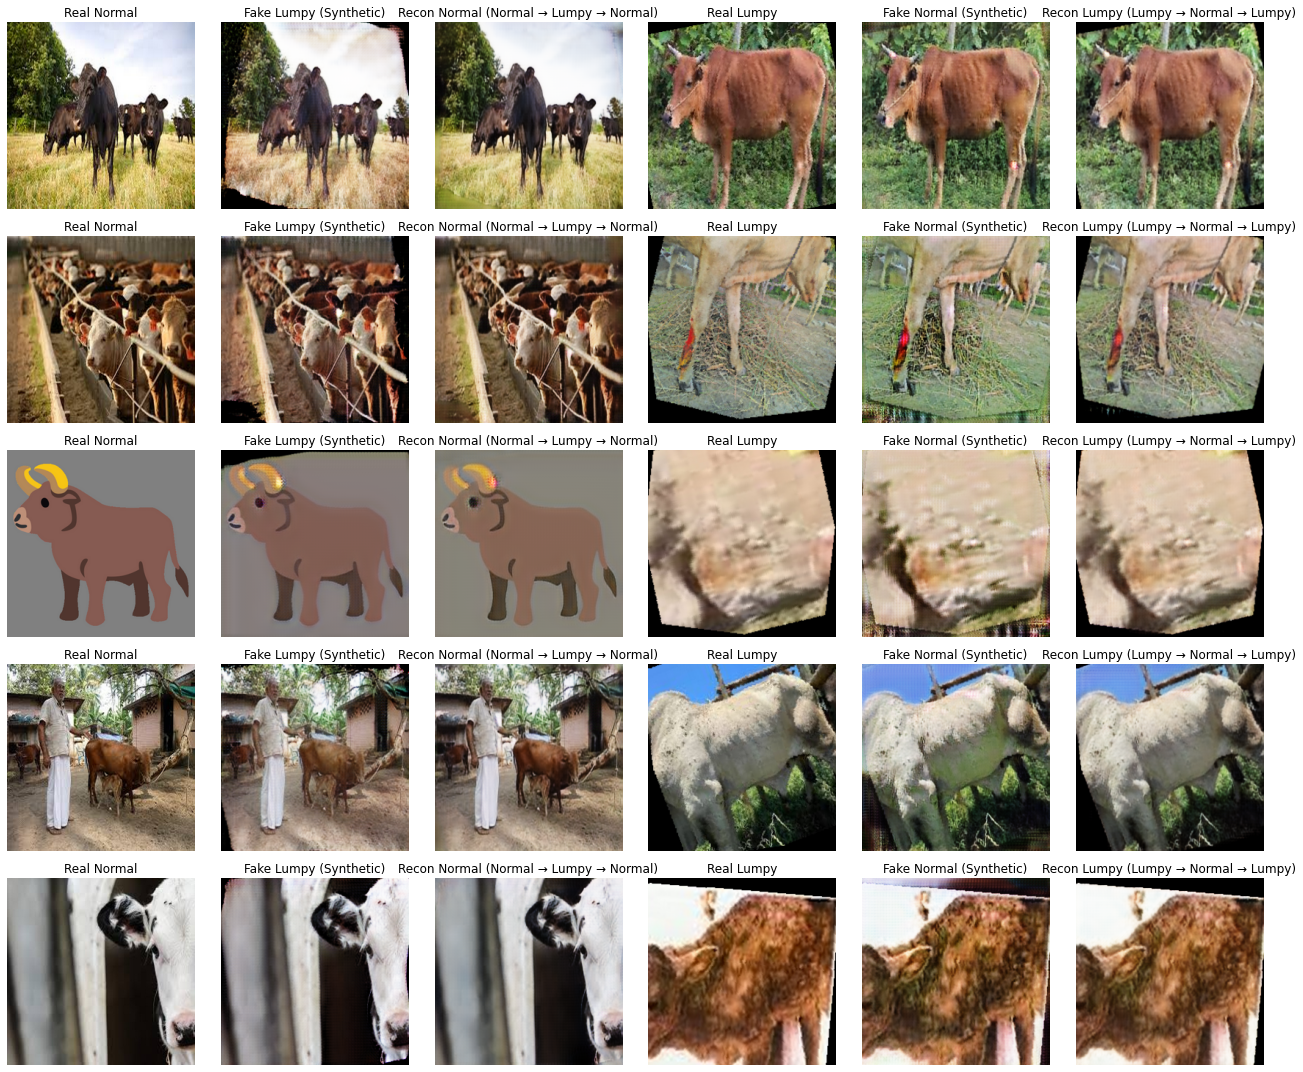

Generating synthetic images: 100%|███████████▉| 818/819 [00:43<00:00, 18.87it/s]


> Synthetic images saved to synthetic_images/lumpy_skin and synthetic_images/healthy_skin.
> Total synthetic healthy skin images generated: 560
> Total synthetic lumpy skin images generated: 819


In [27]:
g_model_AtoB = Generator().to(device)
g_model_BtoA = Generator().to(device)
d_model_A = Discriminator(input_shape=(3, 256, 256)).to(device)
d_model_B = Discriminator(input_shape=(3, 256, 256)).to(device)

optim_g = optim.Adam(list(g_model_AtoB.parameters()) + list(g_model_BtoA.parameters()), lr=0.0002, betas=(0.5, 0.999))
optim_d_A = optim.Adam(d_model_A.parameters(), lr=0.0002, betas=(0.5, 0.999))
optim_d_B = optim.Adam(d_model_B.parameters(), lr=0.0002, betas=(0.5, 0.999))

n_patch = 256
poolA, poolB = [], []
num_epochs = 200

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

g_model_AtoB = g_model_AtoB.to(device)
g_model_BtoA = g_model_BtoA.to(device)

best_val_metric = float('inf')

class_weights = torch.tensor([1.0, 2.0]).to(device)  

# Training loop
for epoch in range(num_epochs):
    g_model_AtoB.train()  
    g_model_BtoA.train()

    for batch_idx, batch in enumerate(train_loader):
        real_A = batch['A'].to(device)
        real_B = batch['B'].to(device)

        # Forward pass through generators 
        fake_B = g_model_AtoB(real_A) 
        fake_A = g_model_BtoA(real_B)  
        

        # Discriminator A Update 
        optim_d_A.zero_grad()
        real_loss_A = torch.mean((d_model_A(real_A) - 1) ** 2)
        fake_loss_A = torch.mean(d_model_A(fake_A.detach()) ** 2)
        d_loss_A = (real_loss_A + fake_loss_A) * 0.5
        d_loss_A.backward()
        optim_d_A.step()

        # Discriminator B Update 
        optim_d_B.zero_grad()
        real_loss_B = torch.mean((d_model_B(real_B) - 1) ** 2)
        fake_loss_B = torch.mean(d_model_B(fake_B.detach()) ** 2)
        d_loss_B = (real_loss_B + fake_loss_B) * 0.5
        d_loss_B.backward()
        optim_d_B.step()

        # Generator Update (AtoB and BtoA) 
        optim_g.zero_grad()
        adv_loss_AtoB = torch.mean((d_model_B(fake_B) - 1) ** 2)
        adv_loss_BtoA = torch.mean((d_model_A(fake_A) - 1) ** 2)

        # Cycle consistency losses
        cycle_loss_A = torch.mean(torch.abs(g_model_BtoA(fake_B) - real_A))
        cycle_loss_B = torch.mean(torch.abs(g_model_AtoB(fake_A) - real_B))

        # Identity loss
        identity_loss_A = torch.mean(torch.abs(g_model_AtoB(real_A) - real_A)) 
        identity_loss_B = torch.mean(torch.abs(g_model_BtoA(real_B) - real_B))  

        
        g_loss_AtoB = adv_loss_AtoB + 10 * cycle_loss_B + 5 * identity_loss_A
        g_loss_BtoA = adv_loss_BtoA + 10 * cycle_loss_A + 5 * identity_loss_B

        g_loss = g_loss_AtoB + g_loss_BtoA  

        # Calculate the cross-entropy loss for fake images
        logits_fake_B = torch.randn(fake_B.size(0), 2).to(device)  
        logits_fake_A = torch.randn(fake_A.size(0), 2).to(device)  

        targets_fake_B = torch.zeros(fake_B.size(0)).long().to(device)  
        targets_fake_A = torch.ones(fake_A.size(0)).long().to(device)  

        cross_entropy_loss_AtoB = nn.CrossEntropyLoss()(logits_fake_B, targets_fake_B)
        cross_entropy_loss_BtoA = nn.CrossEntropyLoss()(logits_fake_A, targets_fake_A)

        total_g_loss = g_loss + cross_entropy_loss_AtoB + cross_entropy_loss_BtoA


        total_g_loss.backward() 

        optim_g.step()  

       
        # Print logs every 100 batches
        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch + 1}/{num_epochs}], Batch [{batch_idx + 1}/{len(train_loader)}], "
                  f"D Loss A: {d_loss_A.item():.4f}, D Loss B: {d_loss_B.item():.4f}, "
                  f"G Loss AtoB: {g_loss_AtoB.item():.4f}, G Loss BtoA: {g_loss_BtoA.item():.4f}, "
                  f"Identity Loss A: {identity_loss_A.item():.4f}, Identity Loss B: {identity_loss_B.item():.4f}, "
                  f"Cross-Entropy Loss AtoB: {cross_entropy_loss_AtoB.item():.4f}, "
                  f"Cross-Entropy Loss BtoA: {cross_entropy_loss_BtoA.item():.4f}")

            # Validation Phase
            g_model_AtoB.eval()
            g_model_BtoA.eval()

            val_cycle_loss_A, val_cycle_loss_B = 0.0, 0.0
            val_cross_entropy_loss_AtoB, val_cross_entropy_loss_BtoA = 0.0, 0.0

with torch.no_grad():
    for valid_batch in DataLoader(valid_dataset, batch_size=1):
        val_real_A = valid_batch['A'].to(device)
        val_real_B = valid_batch['B'].to(device)

        val_fake_B = g_model_AtoB(val_real_A)
        val_fake_A = g_model_BtoA(val_real_B)

        # Cycle Consistency Loss (Validation)
        val_cycle_loss_A += torch.mean(torch.abs(g_model_BtoA(val_fake_B) - val_real_A)).item()
        val_cycle_loss_B += torch.mean(torch.abs(g_model_AtoB(val_fake_A) - val_real_B)).item()

        # Cross-Entropy Loss for Validation 
        logits_val_fake_B = torch.randn(val_fake_B.size(0), 2).to(device)  
        logits_val_fake_A = torch.randn(val_fake_A.size(0), 2).to(device)
        
        targets_val_fake_B = torch.zeros(val_fake_B.size(0)).long().to(device)  
        targets_val_fake_A = torch.ones(val_fake_A.size(0)).long().to(device)  
        
        val_ce_loss_AtoB = nn.CrossEntropyLoss()(logits_val_fake_B, targets_val_fake_B)
        val_ce_loss_BtoA = nn.CrossEntropyLoss()(logits_val_fake_A, targets_val_fake_A)

        val_cross_entropy_loss_AtoB += val_ce_loss_AtoB.item()
        val_cross_entropy_loss_BtoA += val_ce_loss_BtoA.item()

    # Average losses over validation set
    val_cycle_loss_A /= len(valid_dataset)
    val_cycle_loss_B /= len(valid_dataset)
    val_cross_entropy_loss_AtoB /= len(valid_dataset)
    val_cross_entropy_loss_BtoA /= len(valid_dataset)

    print(f"Epoch [{epoch + 1}/{num_epochs}], "
          f"Validation Cycle Loss A: {val_cycle_loss_A:.4f}, "
          f"Validation Cycle Loss B: {val_cycle_loss_B:.4f}, "
          f"Validation Cross-Entropy Loss AtoB: {val_cross_entropy_loss_AtoB:.4f}, "
          f"Validation Cross-Entropy Loss BtoA: {val_cross_entropy_loss_BtoA:.4f}")


    # Save the best model based on validation performance
    current_val_metric = val_cycle_loss_A + val_cycle_loss_B 

    if current_val_metric < best_val_metric:  # If the current validation metric is better
        best_val_metric = current_val_metric
        print(f"Improved validation metric, saving high-quality synthetic images and models...")
        
     # Visualize results every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch: {epoch + 1}, Visualization Condition: {(epoch + 1) % 10 == 0}")
        
        visualize_results_with_reconstruction(g_model_AtoB, g_model_BtoA, train_dataset, num_samples=5)

   
        save_synthetic_images_with_balanced_dataset(
            g_model_AtoB=g_model_AtoB,
            g_model_BtoA=g_model_BtoA,
            dataset=train_dataset,         
            save_dir_lumpy="synthetic_images/lumpy_skin",  
            save_dir_healthy="synthetic_images/healthy_skin",  
            original_healthy_count=560, 
            original_lumpy_count=259,
            target_healthy_count=1120,
            target_lumpy_count=1078
        )

        save_qualitative_results(
            epoch=epoch,
            g_model_AtoB=g_model_AtoB,
            g_model_BtoA=g_model_BtoA,
            dataset=train_dataset,
            save_dir="qualitative_results"
        )

        # Save models after the best performance
        save_models(
            step=epoch,
            g_model_AtoB=g_model_AtoB,
            g_model_BtoA=g_model_BtoA,
            save_dir="saved_models",
            model_type="best_validation",  
            save_interval=10
        )

    

In [28]:

def count_images_in_folders(folder1, folder2):
    """
    Counts the number of images in two specified folders.
    
    Args:
        folder1 (str): Path to the first folder.
        folder2 (str): Path to the second folder.
    
    Returns:
        None
    """
    def count_images(folder):
        
        return len([file for file in os.listdir(folder) if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))])

    count1 = count_images(folder1)
    count2 = count_images(folder2)

    print(f"Number of images in {folder1}: {count1}")
    print(f"Number of images in {folder2}: {count2}")

normal_image_dir = "/workspace/archive/synthetic_images/healthy_skin"
lumpy_image_dir = "/workspace/archive/synthetic_images/lumpy_skin"

count_images_in_folders(normal_image_dir, lumpy_image_dir)


Number of images in /workspace/archive/synthetic_images/healthy_skin: 560
Number of images in /workspace/archive/synthetic_images/lumpy_skin: 819


In [38]:

original_dataset_path = "/workspace/archive/Lumpy Skin Images Dataset"
synthetic_images_path = "/workspace/archive/synthetic_images"

# Subfolders in the datasets
categories = [("Normal Skin", "healthy_skin"), ("Lumpy Skin", "lumpy_skin")]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

inception_model = models.inception_v3(pretrained=True, transform_input=False)
inception_model.fc = torch.nn.Identity()  
inception_model.eval()  

def get_inception_features(image_folder, model, transform, device):
    image_files = [f for f in os.listdir(image_folder) if f.endswith(('.jpg', '.png'))]
    features = []

    model = model.to(device) 

    with torch.no_grad():
        for img_file in image_files:
            img_path = os.path.join(image_folder, img_file)
            image = Image.open(img_path).convert("RGB")
            image = transform(image).unsqueeze(0).to(device)

            image = torch.nn.functional.interpolate(image, size=(299, 299), mode="bilinear", align_corners=False)

            feature = model(image)

            feature = feature.view(1, -1)  
            features.append(feature.squeeze().cpu().numpy())

    return np.array(features)


def compute_fid(category_pair, original_dataset_path, synthetic_images_path, model, transform, device):
    original_category = category_pair[0]
    synthetic_category = category_pair[1]

    original_folder = os.path.join(original_dataset_path, original_category)
    synthetic_folder = os.path.join(synthetic_images_path, synthetic_category)

    original_features = get_inception_features(original_folder, model, transform, device)
    synthetic_features = get_inception_features(synthetic_folder, model, transform, device)

    if original_features.size == 0 or synthetic_features.size == 0:
        raise ValueError("No valid features extracted. Ensure the folders contain images and the model works properly.")

    # Calculate means and covariances
    mu1, sigma1 = np.mean(original_features, axis=0), np.cov(original_features, rowvar=False)
    mu2, sigma2 = np.mean(synthetic_features, axis=0), np.cov(synthetic_features, rowvar=False)

    # Compute FID
    fid_score = calculate_frechet_distance(mu1, sigma1, mu2, sigma2)
    return fid_score

def calculate_frechet_distance(mu1, sigma1, mu2, sigma2):
    from scipy.linalg import sqrtm
    
    covmean, _ = sqrtm(sigma1 @ sigma2, disp=False)
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid_score = np.sum((mu1 - mu2)**2) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid_score


fid_results = {}
for category_pair in categories:
    try:
        fid_score = compute_fid(category_pair, original_dataset_path, synthetic_images_path, inception_model, transform, device)
        fid_results[category_pair[0]] = fid_score
        print(f"FID for {category_pair[0]}: {fid_score:.4f}")
    except Exception as e:
        print(f"Error computing FID for {category_pair[0]}: {e}")


FID for Normal Skin: 40.6413
FID for Lumpy Skin: 105.3801
